In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [3]:
file_path_DvD = "genes/DMSO vs DHEA.csv"
df = pd.read_csv(file_path_DvD, header=0, sep =';', decimal=',', thousands=None) 
df

,Column1,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_name
0,AT1G49570,28.555486,-7.896463,1.896371,4.163987,0.000031,0.129808,AT1G49570
1,AT3G00400,9.440692,-7.520543,1.662691,4.523116,0.000006,0.052327,AT3G00400
2,AT2G14610,245.305823,-7.130040,1.519035,4.693796,0.000003,0.030706,PR1
3,AT2G44240,3.016673,-7.012571,4.320685,1.623023,0.104584,1.000000,AT2G44240
4,AT3G28510,14.480987,-6.545885,1.394017,4.695700,0.000003,0.030706,AT3G28510
...,...,...,...,...,...,...,...,...
34344,AT3G21040,2.420550,5.006389,1.912962,-2.617087,0.008868,1.000000,NaN
34345,AT5G58170,2.270087,5.025810,1.922521,-2.614176,0.008944,1.000000,SVL5
34346,AT1G12510,2.155389,5.106409,5.867889,-0.870229,0.384175,1.000000,AT1G12510
34347,AT4G06698,1.209073,5.256959,3.279691,-1.602883,0.108961,1.000000,NaN


In [3]:
df.loc[df['gene_name'].str.contains('PCR1', case=False, na=False), 'Column1']


6       AT1G14880
1736    AT1G68610
Name: Column1, dtype: object

In [4]:
df = df.dropna()

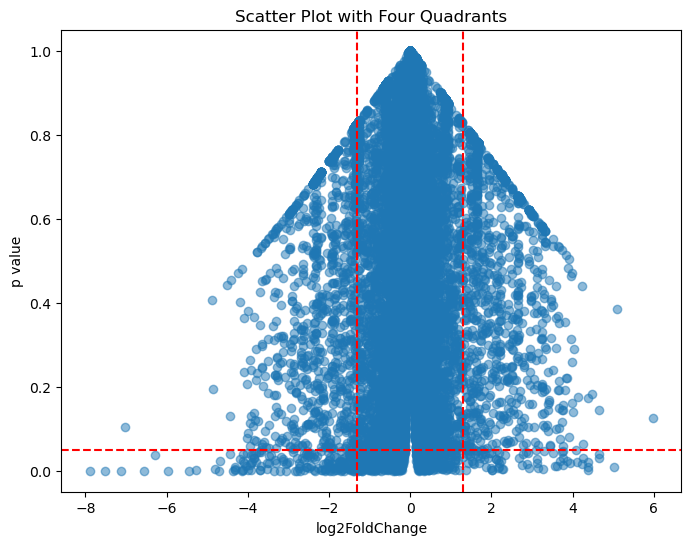

In [5]:
# Create a scatter plot with four quadrants
plt.figure(figsize=(8, 6))
plt.scatter(df['log2FoldChange'], df['pvalue'], alpha=0.5)

# Add vertical and horizontal lines to create quadrants
plt.axvline(x=-1.3, color='red', linestyle='--')
plt.axvline(x=1.3, color='red', linestyle='--')
plt.axhline(y=0.05, color='red', linestyle='--')

# Set labels and title
plt.xlabel('log2FoldChange')
plt.ylabel('p value')
plt.title('Scatter Plot with Four Quadrants')

# Show the plot
plt.show()

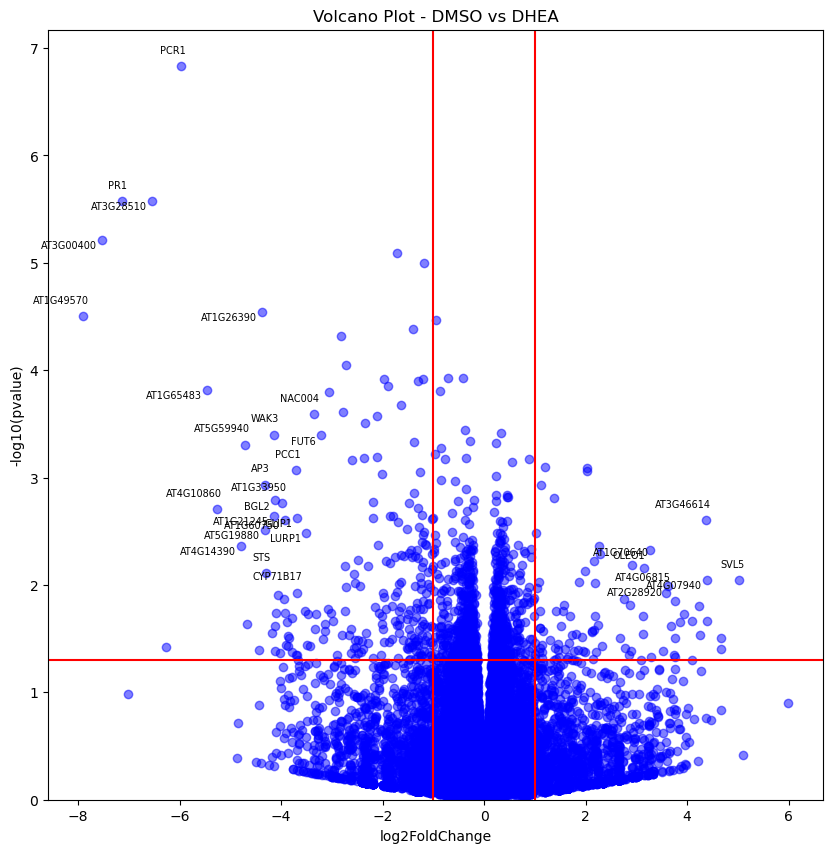

In [5]:
pvalues = df['pvalue']
log2foldchange = df['log2FoldChange']
gene_names = df['gene_name']  # Replace 'gene_name' with the actual column name in your data
neg_log_pvalues = -np.log10(pvalues)

# Create Volcano Plot
plt.figure(figsize=(10, 10))
plt.scatter(log2foldchange, neg_log_pvalues,  color='blue', alpha=0.5)

# Identify extreme points for gene names
extreme_points = (log2foldchange.abs() > log2foldchange.abs().quantile(0.99)) & (neg_log_pvalues > neg_log_pvalues.quantile(0.99))

# Add gene names as text for extreme points
for i, gene_name in enumerate(gene_names[extreme_points]):
    # Offset text to avoid overlap
    x_offset = 0.1 if i % 2 == 0 else -0.1
    y_offset = 0.1 if i % 2 == 0 else -0.1
    plt.text(log2foldchange[extreme_points].iloc[i] + x_offset, neg_log_pvalues[extreme_points].iloc[i] + y_offset, gene_name, fontsize=7, ha='right', va='bottom')

plt.axvline(x=-1, color='red', linestyle='-')
plt.axvline(x=1, color='red', linestyle='-')
plt.axhline(y=1.3, color='red', linestyle='-')

# Customize plot
plt.title('Volcano Plot - DMSO vs DHEA')
plt.xlabel('log2FoldChange')
plt.ylabel('-log10(pvalue)')
plt.ylim(0, plt.ylim()[1])  # Adjust the lower limit based on your preference

plt.savefig('DMSO v DHEA_scatterplot.tiff', format='tiff')

# Show or save the plot
plt.show()

In [11]:
extreme_genes_df = pd.DataFrame({
    'Gene Name': gene_names[extreme_points],
    'Log2FoldChange': log2foldchange[extreme_points],
    '-log10(pvalue)': neg_log_pvalues[extreme_points]
})

# Display the table of extreme genes
print(extreme_genes_df)

       Gene Name  Log2FoldChange  -log10(pvalue)
0      AT1G49570       -7.896463        4.504456
1      AT3G00400       -7.520543        5.215383
2            PR1       -7.130040        5.571865
4      AT3G28510       -6.545885        5.575118
6           PCR1       -5.975083        6.829738
9      AT1G65483       -5.450714        3.817360
10     AT4G10860       -5.272055        2.707391
13     AT4G14390       -4.797981        2.362746
14     AT5G59940       -4.711727        3.307266
20     AT1G26390       -4.369148        4.545155
23           AP3       -4.322706        2.934971
24     AT5G19880       -4.314061        2.514046
25           STS       -4.306412        2.110081
30     AT1G21245       -4.137791        2.644590
31          WAK3       -4.137233        3.400426
34          BGL2       -4.122771        2.787981
47     AT1G33950       -3.985916        2.766598
54     AT1G60750       -3.917521        2.606644
80          PCC1       -3.710176        3.066622
82         GLIP1    

In [42]:
pvalues = df['pvalue']
log2foldchange = df['log2FoldChange']
neg_log_pvalues = -np.log10(pvalues)

for value in neg_log_pvalues:
    if value <= 0 :
        print(value)

-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0


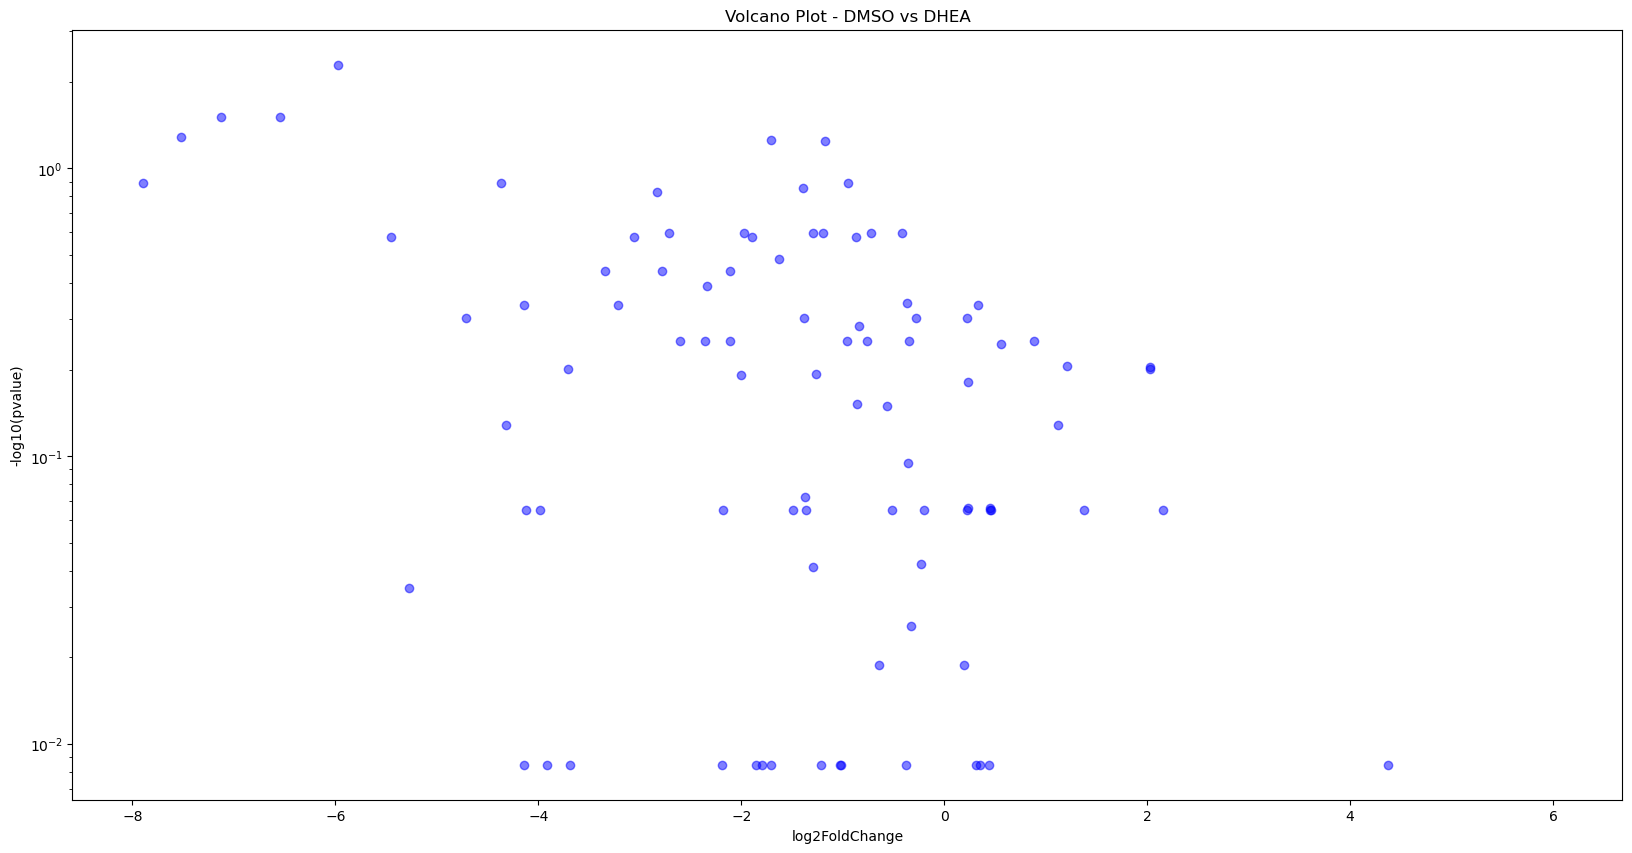

In [26]:


# Create Volcano Plot
plt.figure(figsize=(20, 10))
plt.scatter(log2foldchange, neg_log_pvalues,  color='blue', alpha=0.5)

# Customize plot
plt.title('Volcano Plot - DMSO vs DHEA')
plt.xlabel('log2FoldChange')
plt.ylabel('-log10(pvalue)')
plt.yscale('log')  # Display p-values on a logarithmic scale

# Show or save the plot
plt.show()

In [53]:
file_path_DvS = "genes/DMSO vs Spore.csv"
df_DvS = pd.read_csv(file_path_DvS, header=0, sep =';', decimal=',', thousands=None) 
df_DvS.head()

,Column1,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_name
0,AT1G04063,0.074590,0.0,5.948279,0.0,1.0,NaN,AT1G04063
1,AT1G01890,0.028355,0.0,5.948279,0.0,1.0,NaN,AT1G01890
2,AT1G04087,0.027792,0.0,5.948279,0.0,1.0,NaN,AT1G04087
3,AT1G02813,0.355624,0.0,3.937513,0.0,1.0,NaN,AT1G02813
4,AT1G02830,0.208346,0.0,5.948279,0.0,1.0,NaN,AT1G02830


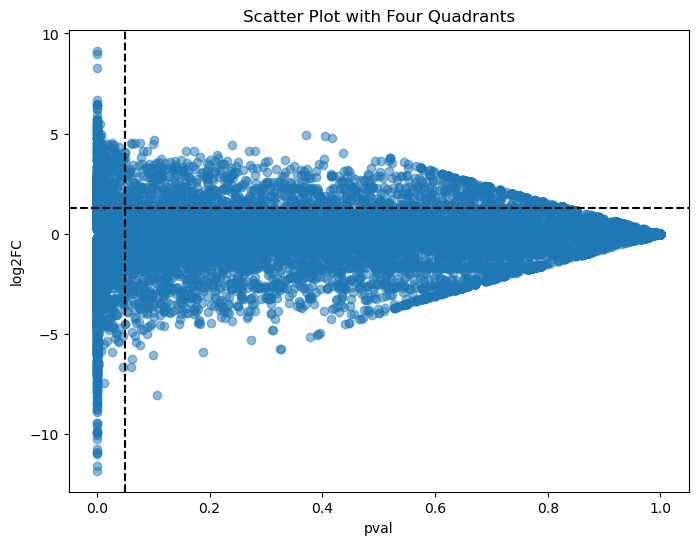

In [54]:
# Create a scatter plot with four quadrants
plt.figure(figsize=(8, 6))
plt.scatter(df_DvS['pvalue'],df_DvS['log2FoldChange'],  alpha=0.5)

# Add vertical and horizontal lines to create quadrants
plt.axvline(x=0.05, color='black', linestyle='--')
plt.axhline(y=1.3, color='black', linestyle='--')

# Set labels and title
plt.xlabel('pval')
plt.ylabel('log2FC')
plt.title('Scatter Plot with Four Quadrants')

# Show the plot
plt.show()

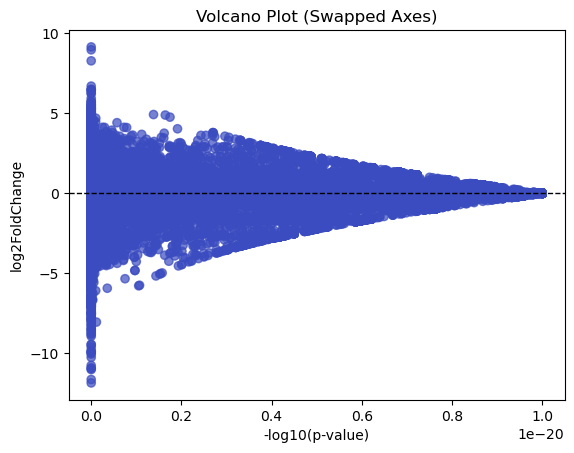

In [55]:
# Customize the colors based on significance
plt.scatter(-1 * df_DvS['pvalue'].apply(lambda x: -1 * (10**-10) * (x+1e-10)).apply(lambda x: -1 * (x**2)), df_DvS['log2FoldChange'], c=(df['padj'] < 0.05) & (df['log2FoldChange'].abs() > 1), cmap='coolwarm', alpha=0.7)

# Add horizontal lines for visual aid
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)

# Set labels and title
plt.xlabel('-log10(p-value)')
plt.ylabel('log2FoldChange')
plt.title('Volcano Plot (Swapped Axes)')

# Show the plot
plt.show()

In [15]:
genes_with_nan = df[df['gene_name'].isna()]

# Display the list of genes with 'nan' names
print(genes_with_nan)

         Column1  baseMean  log2FoldChange     lfcSE      stat    pvalue  \
7      AT3G22238  2.277692       -5.558815  4.874404  1.140409  0.254116   
8      AT3G22234  2.366999       -5.523493  2.638589  2.093351  0.036318   
21     AT2G06590  1.368868       -4.368207  1.832315  2.383982  0.017126   
22     AT3G43563  1.738729       -4.357699  2.068769  2.106422  0.035168   
35     AT3G45120  9.295419       -4.122769  1.548697  2.662088  0.007766   
...          ...       ...             ...       ...       ...       ...   
34326  AT1G32830  2.394058        4.067144  1.880631 -2.162648  0.030568   
34329  AT3G32894  0.360407        4.138445  5.875275 -0.704383  0.481194   
34337  AT3G17200  0.649176        4.379011  5.183295 -0.844832  0.398205   
34344  AT3G21040  2.420550        5.006389  1.912962 -2.617087  0.008868   
34347  AT4G06698  1.209073        5.256959  3.279691 -1.602883  0.108961   

       padj gene_name  
7       1.0       NaN  
8       1.0       NaN  
21      1.0    